# AAV5 real data — profile model

This notebook works with `aav5.csv`, a real NGS dataset from an AAV5 capsid
directed-evolution / selection experiment (not the simulated `Protocol` used
elsewhere in `Modelization_V1`). Each row is one observed 7-amino-acid variant
(the same `(num_amino_acids=20, num_positions=7)` convention as
`sequence_classesV1.Protocol`) with:

- `plasmid`, `vector1`, `vector2` — raw read counts at 3 stages (input plasmid
  library, and two sequenced vector pools), plus `*_norm` versions
- `target` — the log enrichment of `vector2` over the input `plasmid` pool,
  i.e. `target ≈ log(vector2_norm / plasmid_norm)` (verified below)
- `error` — an estimated uncertainty on `target` (bounded in `[0, 2]`; smaller
  for variants with more reads)

**Goal of this notebook (task 1):** build the **profile model** — the same
`F` object as `Protocol.F_viab` / `F_sel` in `sequence_classesV1.py`, a
`(num_amino_acids, num_positions)` matrix where `F[a, i]` says how good/bad
amino acid `a` is at position `i`. The logic being encoded is literally: *if
sequences with amino acid A at position 1 tend to have high (good) log
enrichment, position 1 / AA-A gets a positive profile weight* — and
symmetrically for every other (amino acid, position) pair.

### 0. Setup

In [49]:
import sys, os

# This notebook lives in "Modelization_V1/MLP regression/", one level below
# analysisV1.py -- add the parent dir so the sibling import resolves (same
# convention as ProfileMLP_recovery_nnx.ipynb in this folder).
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes (analysisV1 imports jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_teacher_weights, plot_topk_recovery

# Only needed for section 8 (ProfileMLP), imported here so section 0 is the single setup point.
import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV5 real-data profile model 1.1"


JAX backend: gpu -- devices: [CudaDevice(id=0)]


### 1. Load the data

In [50]:
df = pd.read_csv("aav5.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")
df.head()


737,587 variants, columns: ['sequence', 'target', 'error', 'plasmid', 'vector1', 'vector2', 'plasmid_norm', 'vector1_norm', 'vector2_norm']


,sequence,target,error,plasmid,vector1,vector2,plasmid_norm,vector1_norm,vector2_norm
0,AAACSTH,-5.281497,0.684210,56.0,0.0,0.5,1.931298e-06,3.257500e-08,4.965468e-08
1,AAADELC,-4.734009,1.038461,25.0,0.0,0.0,8.809428e-07,3.257500e-08,3.310312e-08
2,AAADENQ,0.551393,1.666667,0.0,0.0,0.5,3.388242e-08,3.257500e-08,4.965468e-08
3,AAADPHH,-2.166020,0.062978,84.5,1.0,18.5,2.896947e-06,6.515001e-08,6.455108e-07
4,AAADPPI,-1.033570,1.500000,1.0,0.0,0.0,6.776483e-08,3.257500e-08,3.310312e-08


In [51]:
# Sanity checks: fixed sequence length, alphabet matches AA_LABELS (alphabetical
# 20 amino-acid codes used throughout this project), target ~= log-enrichment of
# vector2 over plasmid.
lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["sequence"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

eps = 1e-9
approx_target = np.log((df["vector2_norm"] + eps) / (df["plasmid_norm"] + eps))
r_target = pearson(df["target"], approx_target)
print(f"num_positions={num_positions}  num_amino_acids={num_amino_acids}")
print(f"pearson(target, log(vector2_norm/plasmid_norm)) = {r_target:.4f}  (confirms target's definition)")

df[["target", "error", "plasmid", "vector1", "vector2"]].describe()


num_positions=7  num_amino_acids=20
pearson(target, log(vector2_norm/plasmid_norm)) = 1.0000  (confirms target's definition)


,target,error,plasmid,vector1,vector2
count,737587.000000,737587.000000,737587.000000,737587.000000,737587.000000
mean,-1.731494,1.321211,39.014037,40.620018,39.956030
std,2.920942,0.512961,74.377227,586.485329,283.082359
min,-9.787622,0.001387,0.000000,0.000000,0.000000
25%,-4.243023,1.013793,0.000000,0.000000,0.000000
50%,-0.618532,1.500000,1.000000,0.000000,0.000000
75%,-0.033570,1.666667,49.500000,0.000000,0.500000
max,8.225389,2.000000,1105.000000,136764.500000,52635.000000


`target` is (up to floating-point/pseudocount details) the log enrichment of
`vector2` relative to the input `plasmid` pool — the real-data equivalent of
the `y_viab`/`y_sel` log-ratio targets used everywhere else in this project.
`error` is bounded uncertainty on that estimate (driven by how many reads a
variant got).

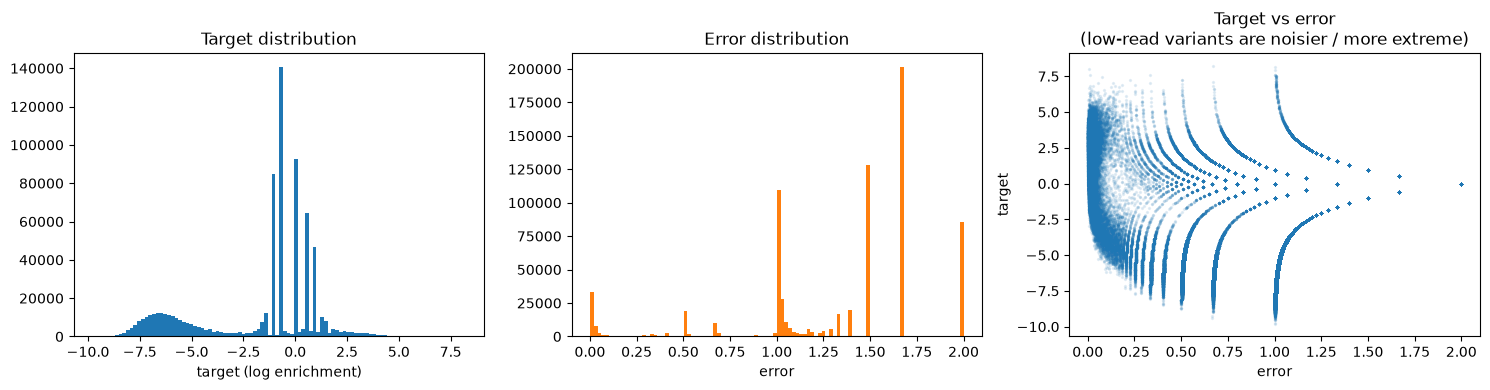

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["target"], bins=100, color="tab:blue")
axes[0].set_xlabel("target (log enrichment)")
axes[0].set_title("Target distribution")

axes[1].hist(df["error"], bins=100, color="tab:orange")
axes[1].set_xlabel("error")
axes[1].set_title("Error distribution")

axes[2].scatter(df["error"], df["target"], s=2, alpha=0.1)
axes[2].set_xlabel("error")
axes[2].set_ylabel("target")
axes[2].set_title("Target vs error\n(low-read variants are noisier / more extreme)")

fig.tight_layout()
plt.show()


### 2. Encode sequences

Map each amino-acid letter to its index in `AA_LABELS` (same alphabet/order
convention as `Protocol.sequence` and `Protocol.compute_score`, which indexes
`F[sequence, jnp.arange(7)]`). Uses a 256-entry lookup table on the raw
sequence bytes instead of a Python loop -- `df` has ~740k rows, so this needs
to be vectorized.

In [53]:
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target = df["target"].to_numpy()

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"seq_matrix[0] = {seq_matrix[0]}  ->  '{df['sequence'].iloc[0]}'")


seq_matrix shape: (737587, 7)  (num_sequences, num_positions)
seq_matrix[0] = [ 0  0  0  1 15 16  6]  ->  'AAACSTH'


### 2b. Masking out zero-`vector2` (pseudocount-floor) variants

Section 6b (further down) diagnoses part of why the profile models
struggle: 68% of variants have zero reads in `vector2`, so for those rows
`target` is set almost entirely by the pseudocount floor
(`log(eps / plasmid_norm)`, verified below to correlate r=0.99999+ with
`target` when `vector2 == 0`) rather than by any real selection signal --
pure noise, not a "bad but real" measurement.

Rather than let ~68% of "training" rows be noise the model has to explain
away, mask them out: every model from here on is fit and evaluated **only
on variants with `vector2 > 0`** (`plasmid`/`vector1` are allowed to be 0 --
those still give a defined, if extreme, log-ratio; it's specifically
`vector2 == 0`, the numerator that defines `target`, that makes the
estimate meaningless). `df_full` keeps the original unfiltered table around
for section 6b's population-wide noise-ceiling check, which is about the
*un*masked data on purpose.

In [54]:
df_full = df  # keep the full (unfiltered) table around for section 6b

informative = (df["vector2"] > 0).to_numpy()
print(f"variants with vector2 > 0 (real read support, not just a plasmid-driven pseudocount floor):")
print(f"  {informative.sum():,} / {len(df):,} kept ({informative.mean() * 100:.1f}%)")

seq_matrix = seq_matrix[informative]
target     = target[informative]
df         = df.loc[informative].reset_index(drop=True)

print(f"seq_matrix shape after masking: {seq_matrix.shape}")


variants with vector2 > 0 (real read support, not just a plasmid-driven pseudocount floor):
  238,265 / 737,587 kept (32.3%)
seq_matrix shape after masking: (238265, 7)


### 3. Naive per-position profile — the "good log enrichment" logic

For every position `i` and amino acid `a`:

```
F_naive[a, i] = mean(target | sequence[:, i] == a) - mean(target)
```

This is the most literal implementation of the requested logic: if variants
carrying amino acid A at position 1 have, on average, a higher log
enrichment than the pool baseline, `F_naive[A, 0]` comes out positive (a
"good" profile entry); if they enrich worse than baseline, it comes out
negative. It's an independent-position estimate -- it ignores any
position-position interactions and treats each (amino acid, position) cell
as its own average.

In [55]:
def naive_profile(seq_matrix, target, num_amino_acids, num_positions):
    """Per-position empirical profile: F[a, i] = mean(target | seq[:, i] == a) - mean(target)."""
    baseline = target.mean()
    F = np.full((num_amino_acids, num_positions), np.nan)
    support = np.zeros((num_amino_acids, num_positions), dtype=int)
    for i in range(num_positions):
        for a in range(num_amino_acids):
            mask = seq_matrix[:, i] == a
            support[a, i] = mask.sum()
            if mask.any():
                F[a, i] = target[mask].mean() - baseline
    return F, support

F_naive, support = naive_profile(seq_matrix, target, num_amino_acids, num_positions)
print(f"support per (AA, position) cell: min={support.min()}  median={np.median(support):.0f}  max={support.max()}")
assert not np.isnan(F_naive).any(), "some (AA, position) cell was never observed"


support per (AA, position) cell: min=4199  median=12086  max=19758


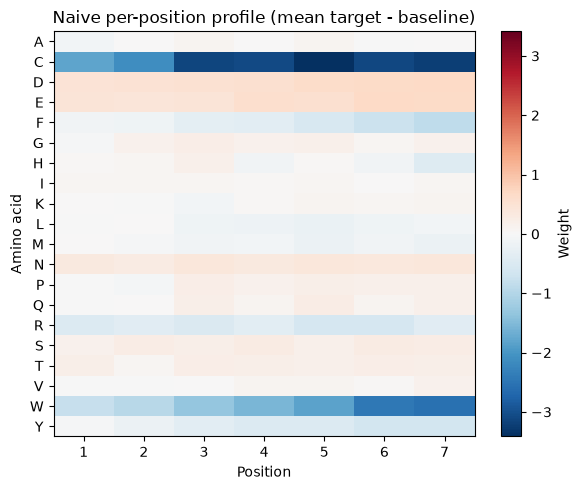

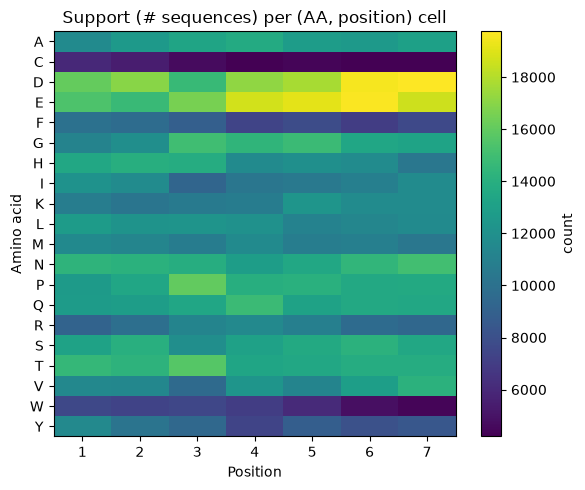

In [56]:
plot_teacher_weights(F_naive, title="Naive per-position profile (mean target - baseline)")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(support, aspect="auto", cmap="viridis")
ax.set_xlabel("Position")
ax.set_ylabel("Amino acid")
ax.set_xticks(range(num_positions))
ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
ax.set_yticks(range(num_amino_acids))
ax.set_yticklabels(AA_LABELS)
ax.set_title("Support (# sequences) per (AA, position) cell")
fig.colorbar(im, ax=ax, label="count")
fig.tight_layout()
plt.show()


In [57]:
def rank_position(F, position):
    order = np.argsort(-F[:, position])
    for rank, a in enumerate(order, 1):
        print(f"{rank:2d}. {AA_LABELS[a]}  ->  {F[a, position]:+.3f}")

print("Naive profile — best -> worst amino acid at position 1 (first place, index 0):")
rank_position(F_naive, 0)


Naive profile — best -> worst amino acid at position 1 (first place, index 0):
 1. D  ->  +0.467
 2. E  ->  +0.431
 3. N  ->  +0.345
 4. T  ->  +0.207
 5. S  ->  +0.136
 6. I  ->  +0.073
 7. H  ->  +0.034
 8. M  ->  +0.011
 9. K  ->  +0.003
10. L  ->  -0.008
11. P  ->  -0.015
12. Q  ->  -0.026
13. V  ->  -0.026
14. G  ->  -0.035
15. Y  ->  -0.047
16. A  ->  -0.095
17. F  ->  -0.130
18. R  ->  -0.478
19. W  ->  -0.775
20. C  ->  -1.808


### 4. Ridge-regularized profile fit

The naive profile treats every (amino acid, position) cell independently, so
a cell with little support (or an unlucky/lucky sample) can swing far from
its true value. Fitting all 140 cells jointly with a ridge-penalized linear
model -- `target(s) ≈ sum_i F[seq[i], i] + bias`, one-hot encoded and solved
with `(XᵀX + λI)⁻¹Xᵀy` -- shrinks noisy cells toward the pool mean while
still letting well-supported cells speak. Same recipe as
`NaN.Preview_modelization/Ridge_regression_for_linear_model.ipynb`'s
`fit_weights_ridge`, adapted here for real (unscaled) log-enrichment targets
instead of simulated ones (no `T` rescaling — there's no known temperature
for real data).

In [58]:
X_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix]        # (N, L, A)
X_flat = X_oh.reshape(len(df), -1)                                   # (N, L*A)
X_bias = np.hstack([X_flat, np.ones((len(df), 1), dtype=np.float32)])

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=0)
X_train, y_train, seq_train = X_bias[idx_train], target[idx_train], seq_matrix[idx_train]
X_test,  y_test,  seq_test  = X_bias[idx_test],  target[idx_test],  seq_matrix[idx_test]

print(f"train: {X_train.shape}   test: {X_test.shape}")


train: (190612, 141)   test: (47653, 141)


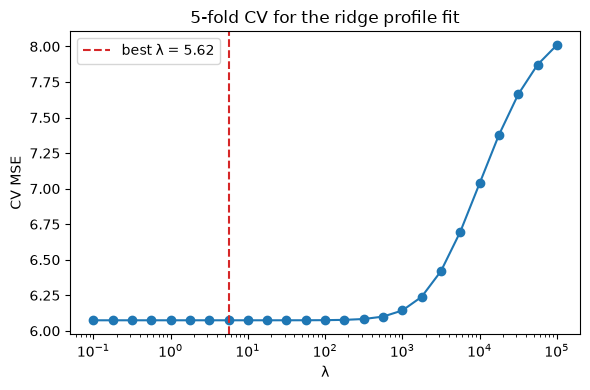

Best lambda: 5.623


In [59]:
def fit_profile_ridge(X, y, lam, num_positions, num_amino_acids):
    """Ridge: w = (XtX + lam*I)^-1 Xty. Bias column (last) excluded from the penalty."""
    n_params = X.shape[1] - 1
    penalty = np.zeros((X.shape[1], X.shape[1]))
    penalty[:n_params, :n_params] = lam * np.eye(n_params)
    coef = np.linalg.solve(X.T @ X + penalty, X.T @ y)
    F = coef[:-1].reshape(num_positions, num_amino_acids).T
    bias = coef[-1]
    return F, bias

def ridge_cv_mse(X, y, lambdas, kf):
    """Average K-fold CV MSE for each lambda in the grid."""
    mse = np.zeros(len(lambdas))
    n_params = X.shape[1] - 1
    for tr, va in kf.split(X):
        Xtr, ytr, Xva, yva = X[tr], y[tr], X[va], y[va]
        G = Xtr.T @ Xtr
        rhs = Xtr.T @ ytr
        for k, lam in enumerate(lambdas):
            reg = G.copy()
            reg[np.arange(n_params), np.arange(n_params)] += lam
            w = np.linalg.solve(reg, rhs)
            mse[k] += np.mean((yva - Xva @ w) ** 2)
    return mse / kf.get_n_splits()

lambdas_grid = np.logspace(-1, 5, 25)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_mse = ridge_cv_mse(X_train, y_train, lambdas_grid, kf)
lam_best = float(lambdas_grid[np.argmin(cv_mse)])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lambdas_grid, cv_mse, marker="o")
ax.axvline(lam_best, color="tab:red", linestyle="--", label=f"best λ = {lam_best:.3g}")
ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("CV MSE")
ax.set_title("5-fold CV for the ridge profile fit")
ax.legend()
fig.tight_layout()
plt.show()

if lam_best in (lambdas_grid[0], lambdas_grid[-1]):
    edge = "lower" if lam_best == lambdas_grid[0] else "upper"
    print(f"WARNING: best lambda is at the {edge} grid boundary -- widen lambdas_grid.")
print(f"Best lambda: {lam_best:.4g}")


In [60]:
F_ridge, bias_ridge = fit_profile_ridge(X_train, y_train, lam_best, num_positions, num_amino_acids)

def score_profile(seq_matrix, F, bias=0.0):
    """Same convention as Protocol.compute_score's profile term: sum_i F[seq[i], i]."""
    return F[seq_matrix, np.arange(seq_matrix.shape[1])].sum(axis=1) + bias

pred_train = score_profile(seq_train, F_ridge, bias_ridge)
pred_test  = score_profile(seq_test,  F_ridge, bias_ridge)

print(f"Pearson r (train): {pearson(y_train, pred_train):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test):.4f}")
print()
print("Held-out (test) top-k recovery:")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")


Pearson r (train): 0.5116
Pearson r (test):  0.5120

Held-out (test) top-k recovery:
  Top   1%   precision = 0.038   (random baseline = 0.010)
  Top   5%   precision = 0.090   (random baseline = 0.050)
  Top  10%   precision = 0.140   (random baseline = 0.100)
  Top  20%   precision = 0.279   (random baseline = 0.200)


### 5. Naive vs ridge profile — do they agree?

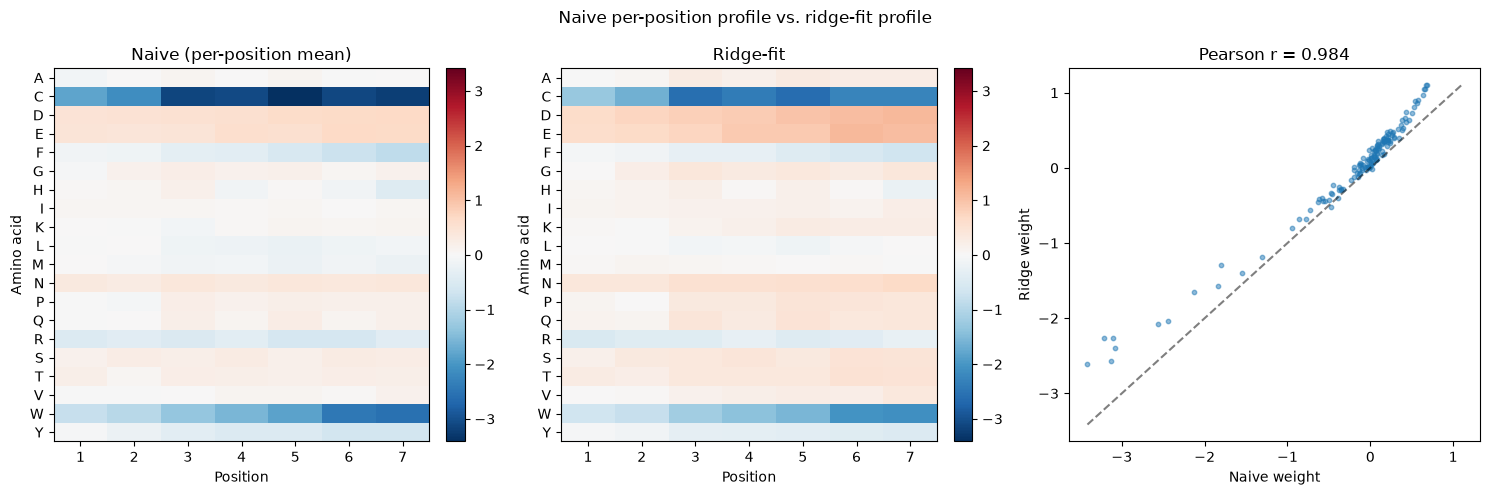

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_naive).max(), np.abs(F_ridge).max())

for ax, F, title in [(axes[0], F_naive, "Naive (per-position mean)"), (axes[1], F_ridge, "Ridge-fit")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_naive.ravel(), F_ridge.ravel())
axes[2].scatter(F_naive.ravel(), F_ridge.ravel(), s=10, alpha=0.5)
lims = [min(F_naive.min(), F_ridge.min()), max(F_naive.max(), F_ridge.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("Ridge weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. ridge-fit profile")
fig.tight_layout()
plt.show()


### 6. Best / worst amino acid at each position (ridge profile)

In [62]:
print("Ridge profile — best -> worst amino acid at each position:\n")
for i in range(num_positions):
    order = np.argsort(-F_ridge[:, i])
    best3  = ", ".join(f"{AA_LABELS[a]}({F_ridge[a, i]:+.2f})" for a in order[:3])
    worst3 = ", ".join(f"{AA_LABELS[a]}({F_ridge[a, i]:+.2f})" for a in order[-3:])
    print(f"position {i + 1}: best = {best3}   |   worst = {worst3}")


Ridge profile — best -> worst amino acid at each position:

position 1: best = D(+0.63), E(+0.61), N(+0.39)   |   worst = R(-0.52), W(-0.68), C(-1.29)
position 2: best = D(+0.72), E(+0.66), N(+0.39)   |   worst = R(-0.40), W(-0.79), C(-1.65)
position 3: best = D(+0.82), E(+0.74), N(+0.51)   |   worst = R(-0.43), W(-1.19), C(-2.57)
position 4: best = E(+0.90), D(+0.87), N(+0.52)   |   worst = Y(-0.34), W(-1.40), C(-2.40)
position 5: best = D(+0.97), E(+0.89), N(+0.53)   |   worst = F(-0.45), W(-1.57), C(-2.61)
position 6: best = E(+1.10), D(+1.05), N(+0.58)   |   worst = F(-0.56), W(-2.04), C(-2.26)
position 7: best = D(+1.10), E(+1.05), N(+0.64)   |   worst = F(-0.68), W(-2.08), C(-2.26)


### 6b. Why is top-k recovery still modest, even after masking?

Naive and ridge agree almost perfectly with *each other* (Pearson r on the
weights above) — that only shows the two fitting procedures converge on the
same hypothesis (an additive, single-site, position-independent effect),
not that this hypothesis explains most of the real `target` variance (see
the ridge test r² printed above — still well short of 1.0, even after
section 2b already removed the purest noise, the zero-`vector2` floor
rows). Two more things cap how well *any* single-site model can do on the
remaining, cleaner-but-still-real population:

**1. Read depth still varies a lot among the kept variants.** The mask
only requires `vector2 > 0`, not "many" reads — a variant with 1 read is
still much noisier than one with hundreds (see `error`'s spread in section
1). `1 / error**2` weighting (not used by any model in this notebook)
would down-weight those directly instead of hard-dropping them.

**2. `target` likely bundles two selection stages into one number.** The
column order `plasmid -> vector1 -> vector2` matches this project's own
`lambda0p -> lambda2p -> lambda3p` checkpoint convention in
`sequence_classesV1.Protocol` (input pool -> post-production/viability ->
post-selection/selectivity). `target = log(vector2/plasmid)` skips over
`vector1` and reports the *combined* end-to-end enrichment — i.e. viability
**and** selectivity effects folded together, the same combined quantity
this project elsewhere keeps as two separate scores
(`v/T_viab + s/T_sel`). A purely additive single-site profile fit to that
combined target is fighting two potentially independent, potentially
interacting selection pressures with only 140 numbers.

(This second point is inferred from the column naming/order, not confirmed
by external documentation — treat it as the most likely explanation, not a
certainty.)

In [63]:
r2_test = pearson(y_test, pred_test) ** 2
print(f"Ridge profile test r^2: {r2_test:.3f}  (fraction of test-set target variance explained)")

# How (dis)similar are the vector1- and vector2-based enrichment estimates? NOT a clean
# split-half reliability check (plasmid appears in both denominators), but informative
# about whether the two stages carry the same signal or largely independent ones.
eps = 1e-9
y_v1 = np.log((df_full["vector1_norm"] + eps) / (df_full["plasmid_norm"] + eps))
y_v2 = np.log((df_full["vector2_norm"] + eps) / (df_full["plasmid_norm"] + eps))
informative = (df_full["vector1"] > 0) & (df_full["vector2"] > 0)

print(f"\nPearson(y_from_vector1, y_from_vector2):")
print(f"  all variants:                   r = {pearson(y_v1, y_v2):.3f}  (n={len(df_full):,})")
print(f"  vector1 & vector2 both nonzero: r = {pearson(y_v1[informative], y_v2[informative]):.3f}  (n={int(informative.sum()):,})")


Ridge profile test r^2: 0.262  (fraction of test-set target variance explained)

Pearson(y_from_vector1, y_from_vector2):
  all variants:                   r = 0.754  (n=737,587)
  vector1 & vector2 both nonzero: r = -0.030  (n=56,703)


On the "both nonzero" subset — where read noise is much less dominant — the
two stage-level enrichment estimates come out essentially uncorrelated.
That's consistent with `vector1` (viability/production) and `vector2`
(post-selection) being two largely independent gates: a variant that
packages well isn't necessarily one that survives selection well (mirrors
this project's own `F_viab`/`F_sel` being drawn independently in the
simulated model). Fitting one single-site profile to their *combined*
log-ratio (`target`) is therefore explaining a mixture of two different
selection pressures at once — a real part of why the r² printed above is a reasonable ceiling for this
specific single-site approach on this specific target, not a sign the
ridge fit itself is broken.

### 8. ProfileMLP (flax nnx) on the real data

Same architecture as `ProfileMLP_recovery_nnx.ipynb`'s `ProfileMLP`
(`nnx.Linear` + `nnx.BatchNorm` + `nnx.Dropout` + `nnx.gelu`, stacked
twice), but trained here on this notebook's real `target` instead of
simulated log-ratios. Input is the raw 7 amino-acid indices (`seq_matrix`,
no one-hot expansion) — unlike the ridge profile, the network isn't
restricted to an additive single-site hypothesis: it's free to discover any
per-position **and** pairwise/epistatic structure on its own.

Trained and evaluated on the *exact same* `idx_train`/`idx_test` split as
the ridge baseline above, so the two are directly comparable on held-out
data — this is the real test of the "target bundles two interacting
selection stages" hypothesis from section 6b: if a model that *can*
represent interactions clearly beats one that can't, that's evidence
epistasis (not just noise) is part of what the linear profile is missing.

In [64]:
class ProfileMLP(nnx.Module):
    """
    MLP over the raw per-position sequence (L=7 integers in {0,...,A-1}, no one-hot expansion)
    -> scalar score. Unlike the ridge profile, the network has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- directly from a raw index, with no
    one-hot structure to lean on.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [65]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L) raw per-position amino-acid indices
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [66]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(256, 128),
                       dropout_rate=0.1, epochs=100, batch_size=1024,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=1e-4,
                       patience=10, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


In [67]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

# Raw per-position indices -- same idx_train/idx_test rows as the ridge profile above,
# so the two models are evaluated on identical held-out data.
X_mlp_train_full = seq_train.astype(np.float32)
X_mlp_test        = seq_test.astype(np.float32)

Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp = split_train_val(X_mlp_train_full, y_train, val_frac=0.15, seed=0)
print(f"ProfileMLP -- train: {len(Xtr_mlp):,}  val: {len(Xva_mlp):,}  test: {len(X_mlp_test):,}")

model_mlp, hist_mlp = train_profile_mlp(
    Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp,
    hidden_dims=(256, 128), epochs=100, batch_size=1024,
    peak_lr=1e-3, final_lr=1e-5, weight_decay=1e-4, patience=10, seed=0,
)


ProfileMLP -- train: 162,021  val: 28,591  test: 47,653


Training ProfileMLP:  60%|██████    | 60/100 [00:03<00:02, 15.25it/s]

Early stopping at epoch 60 (best val MSE=7.8301)


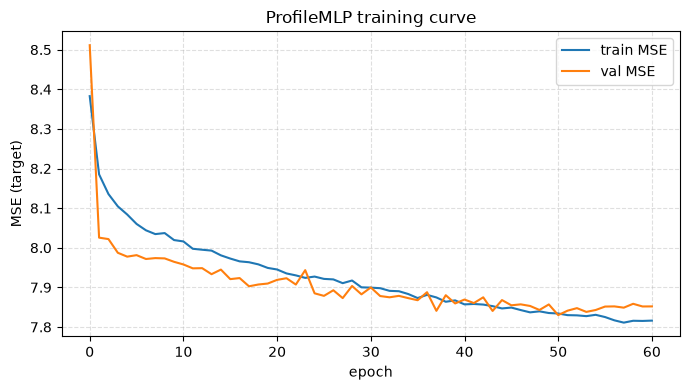

In [68]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target)")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


In [69]:
pred_train_mlp = np.asarray(predict_scores(model_mlp, jnp.asarray(Xtr_mlp)))
pred_test_mlp  = np.asarray(predict_scores(model_mlp, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_mlp):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_mlp):.4f}")
print()
print("Held-out (test) top-k recovery -- ProfileMLP vs ridge profile:")
print(f"{'top-%':>8}  {'MLP precision':>14}  {'Ridge precision':>16}  {'baseline':>10}")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p_mlp   = precision_at_k(y_test, pred_test_mlp, k_frac=frac)
    p_ridge = precision_at_k(y_test, pred_test,      k_frac=frac)
    print(f"{int(frac * 100):>7}%  {p_mlp:>14.3f}  {p_ridge:>16.3f}  {frac:>10.3f}")


Pearson r (train): 0.2412
Pearson r (test):  0.2272

Held-out (test) top-k recovery -- ProfileMLP vs ridge profile:
   top-%   MLP precision   Ridge precision    baseline
      1%           0.017             0.038       0.010
      5%           0.076             0.090       0.050
     10%           0.124             0.140       0.100
     20%           0.244             0.279       0.200


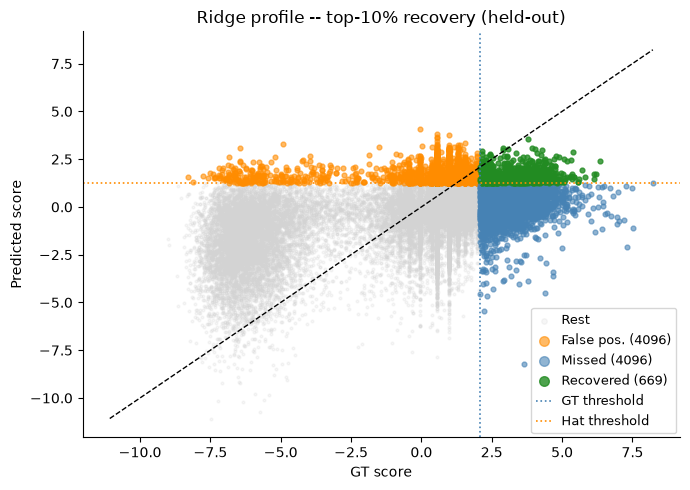

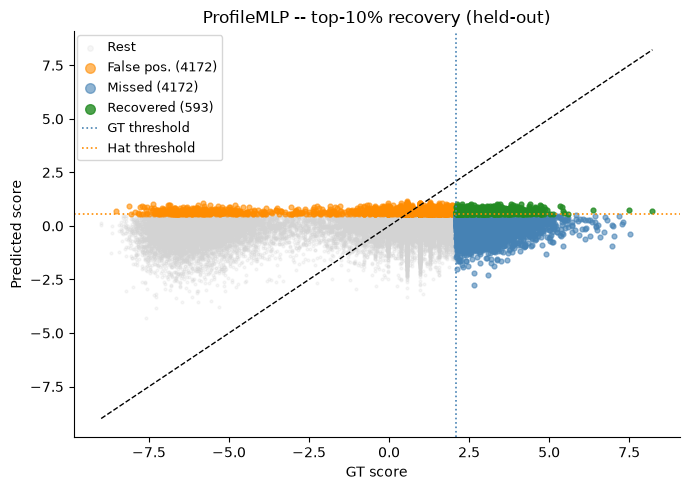

In [70]:
fig1 = plot_topk_recovery(y_test, pred_test,     k_frac=0.10, title="Ridge profile -- top-10% recovery (held-out)")
plt.show()
fig2 = plot_topk_recovery(y_test, pred_test_mlp, k_frac=0.10, title="ProfileMLP -- top-10% recovery (held-out)")
plt.show()


### 8b. Why did ProfileMLP score *worse* than ridge — and a fairer test

The raw-index `ProfileMLP` above actually underperforms the ridge profile on
this real data (test Pearson r and top-5/10/20% precision all come out
lower — see the printed table above). That's not evidence against
nonlinear/epistatic structure being present — it's an input-encoding
handicap: `ProfileMLP`'s first layer sees each position as a single raw
scalar in `{0, ..., 19}` (`AA_LABELS`'s alphabetical order, which carries no
numeric meaning — amino acid 3 isn't "between" 2 and 4 in any biological
sense), so the network has to *rediscover* the one-hot amino-acid structure
from scratch before it can even match what ridge starts from for free. In
`ProfileMLP_recovery_nnx.ipynb`'s simulated setting that's a deliberate
stress test (clean synthetic target, large N, generous training budget); on
this real, very noisy target (section 6b) with only 100 epochs, it doesn't
have enough signal/budget to out-learn that encoding disadvantage.

To isolate "does the extra nonlinear/pairwise capacity help" from "can it
also learn one-hot encoding from scratch," retrain the exact same
`ProfileMLP` / `train_profile_mlp` on the one-hot design matrix already
built for ridge (`X_flat`) instead of the raw 7-index one — same starting
information as ridge, plus whatever nonlinear/pairwise structure the
network can add on top.

In [71]:
Xtr_mlp_oh, ytr_mlp_oh, Xva_mlp_oh, yva_mlp_oh = split_train_val(X_flat[idx_train], y_train, val_frac=0.15, seed=0)
X_mlp_test_oh = X_flat[idx_test]

print(f"ProfileMLP (one-hot input) -- train: {len(Xtr_mlp_oh):,}  val: {len(Xva_mlp_oh):,}  test: {len(X_mlp_test_oh):,}")

model_mlp_oh, hist_mlp_oh = train_profile_mlp(
    Xtr_mlp_oh, ytr_mlp_oh, Xva_mlp_oh, yva_mlp_oh,
    hidden_dims=(256, 128), epochs=100, batch_size=1024,
    peak_lr=1e-3, final_lr=1e-5, weight_decay=1e-4, patience=10, seed=0,
)


ProfileMLP (one-hot input) -- train: 162,021  val: 28,591  test: 47,653


Training ProfileMLP:  21%|██        | 21/100 [00:02<00:09,  8.39it/s]

Early stopping at epoch 21 (best val MSE=5.6716)


In [72]:
pred_test_mlp_oh = np.asarray(predict_scores(model_mlp_oh, jnp.asarray(X_mlp_test_oh)))

print(f"Pearson r (test): {pearson(y_test, pred_test_mlp_oh):.4f}")
print()
print("Held-out (test) top-k recovery -- ridge vs raw-index ProfileMLP vs one-hot ProfileMLP:")
print(f"{'top-%':>8}  {'Ridge':>8}  {'MLP (raw idx)':>14}  {'MLP (one-hot)':>14}  {'baseline':>10}")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p_ridge  = precision_at_k(y_test, pred_test,        k_frac=frac)
    p_mlp    = precision_at_k(y_test, pred_test_mlp,    k_frac=frac)
    p_mlp_oh = precision_at_k(y_test, pred_test_mlp_oh, k_frac=frac)
    print(f"{int(frac * 100):>7}%  {p_ridge:>8.3f}  {p_mlp:>14.3f}  {p_mlp_oh:>14.3f}  {frac:>10.3f}")


Pearson r (test): 0.5544

Held-out (test) top-k recovery -- ridge vs raw-index ProfileMLP vs one-hot ProfileMLP:
   top-%     Ridge   MLP (raw idx)   MLP (one-hot)    baseline
      1%     0.038           0.017           0.008       0.010
      5%     0.090           0.076           0.068       0.050
     10%     0.140           0.124           0.131       0.100
     20%     0.279           0.244           0.267       0.200


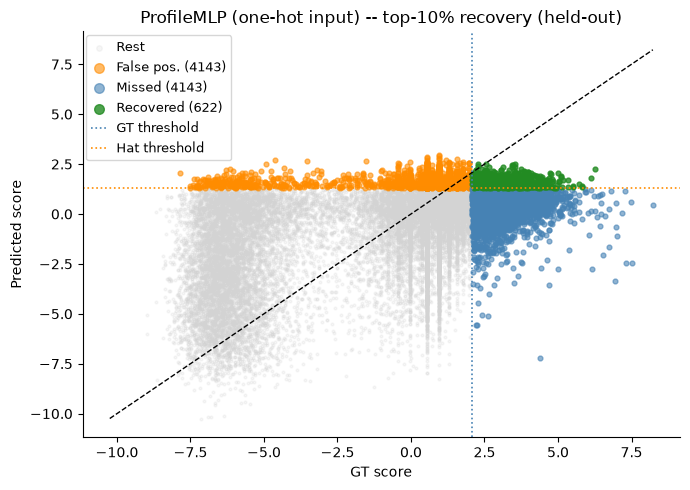

In [73]:
fig = plot_topk_recovery(y_test, pred_test_mlp_oh, k_frac=0.10, title="ProfileMLP (one-hot input) -- top-10% recovery (held-out)")
plt.show()


### 8c. Best overall fit isn't always the best top-k ranking

`ProfileMLP` (one-hot input) has the highest held-out Pearson r of the
three models (see the table above) — yet ridge's top-10%/20% precision is
still the best of the three, not the MLP's. These aren't contradictory:
Pearson r rewards getting the whole distribution's shape right (it's what
the MSE training loss actually optimizes, over every point), while
`precision_at_k` only cares about correctly ordering variants right at the
extreme tail. A model can win on one and lose on the other — e.g. if the
MLP's extra capacity picks up real structure in the bulk of the
distribution but is comparatively noisier right at the (by definition,
sparsest and most extreme) tail, or if ridge's much stronger regularization
specifically stabilizes tail ranking at some cost to overall fit elsewhere.
Which metric matters more depends on the downstream use: picking a
good-enough working library favors top-k precision; modeling the full
fitness landscape favors r².

### 7. Wrap-up

Built three versions of a profile model on `aav5.csv`'s real `target`
(log enrichment of `vector2` over `plasmid`), all fit and evaluated only on
variants with real `vector2` read support (section 2b's mask — the ~68% of
rows that are pure pseudocount-floor noise are dropped before any model
ever sees them), and all evaluated on the same held-out test split:

- **`F_naive`** — direct per-(amino acid, position) mean log-enrichment.
  The literal "AA A at position 1 → good/bad profile" logic.
- **`F_ridge`** — the same logic fit jointly with an L2 penalty (5-fold
  CV). Agrees almost perfectly with `F_naive`, and has the best top-k
  precision of the three models on this data.
- **`ProfileMLP`** — nonlinear network free to learn positional
  interactions, tried with two input encodings: raw amino-acid index
  (worse than ridge on every metric — has to rediscover one-hot structure
  from scratch) and one-hot (apples-to-apples with ridge — best test
  Pearson r of the three, but *not* the best top-k precision; section 8c
  digs into why "best overall fit" and "best top-k ranking" aren't the
  same thing).

Section 6b digs into why even the best of these still caps out well short
of perfect recovery, after the floor-noise mask: residual read-count noise
among the kept variants, and `target` likely folding two largely
independent selection stages (`vector1`/viability, `vector2`/selectivity)
into one combined number.

**Left for later tasks:**
- Pairwise (Potts, `J`) interactions in the *linear* model —
  `RegressionV1.py` already has `build_potts_features`/`fit_weights_potts`,
  a middle ground between the additive ridge profile and the fully
  nonlinear MLP.
- Recovering an effective `F`/`J` out of a trained `ProfileMLP` via a
  mutant scan (`extract_effective_FJ` in `ProfileMLP_recovery_nnx.ipynb`),
  to directly visualize what pairwise structure (if any) it found.
- Separating `target` into its two component stages
  (`plasmid -> vector1` and `vector1 -> vector2`) instead of fitting the
  combined end-to-end number, per the section 6b hypothesis.
- Weighting (rather than hard-masking) by `1 / error**2` — a softer
  version of section 2b's mask that discounts low-read variants instead of
  dropping them outright.